# Items with Yield Distributions

This notebook explores the case where the manufacturing of the items themselves is stochastic. For example, if during baking a certain number of muffins are not sellable, but still cost ingredients to make. The problem then has two sources of uncertainty, the item demand and the item yield.

- how it solves
- how to handle risk
- plots

In [1]:
from optistock.items import Item
from optistock.distributions.demand_distributions import NormalDemand
from optistock.distributions.yield_distributions import BetaYield
from optistock.solvers import StochasticMonteCarloSolver

plain_muffin = Item(
    "plain muffin",
    cost_price=10,
    selling_price=20,
    salvage_value=5,
    constraints={"cost": 10, "storage": 5},
    yield_distribution=BetaYield(5, 1),
)
chocolate_muffin = Item(
    "chocolate muffin",
    cost_price=15,
    selling_price=30,
    salvage_value=8,
    constraints={"cost": 15, "storage": 5},
    yield_distribution=BetaYield(15, 1),
)

plain_demand = NormalDemand(100, 20)
chocolate_demand = NormalDemand(150, 30)

problems = [(plain_muffin, plain_demand), (chocolate_muffin, chocolate_demand)]

limits = {"cost": 2000, "storage": 1000}

# Risk Neutral (Maximize Average Profit)
solver = StochasticMonteCarloSolver(
    problems,
    limits,
    n_samples=5000,
)
res_neutral = solver.solve()
print(f"Risk Neutral Allocation (Lambda=0.0): {res_neutral}")

# Risk adverse
res_averse = solver.solve(risk_aversion=20)
print(f"Risk Averse Allocation  (Lambda=0.9): {res_averse}")

# Analysis
muffin_drop = res_neutral["plain muffin"] - res_averse["plain muffin"]
print(
    f"\nImpact: The solver cut the muffin order by {muffin_drop} units to reduce downside risk."
)

Risk Neutral Allocation (Lambda=0.0): {'plain muffin': np.int64(11), 'chocolate muffin': np.int64(125)}
Risk Averse Allocation  (Lambda=0.9): {'plain muffin': np.int64(37), 'chocolate muffin': np.int64(108)}

Impact: The solver cut the muffin order by -26 units to reduce downside risk.


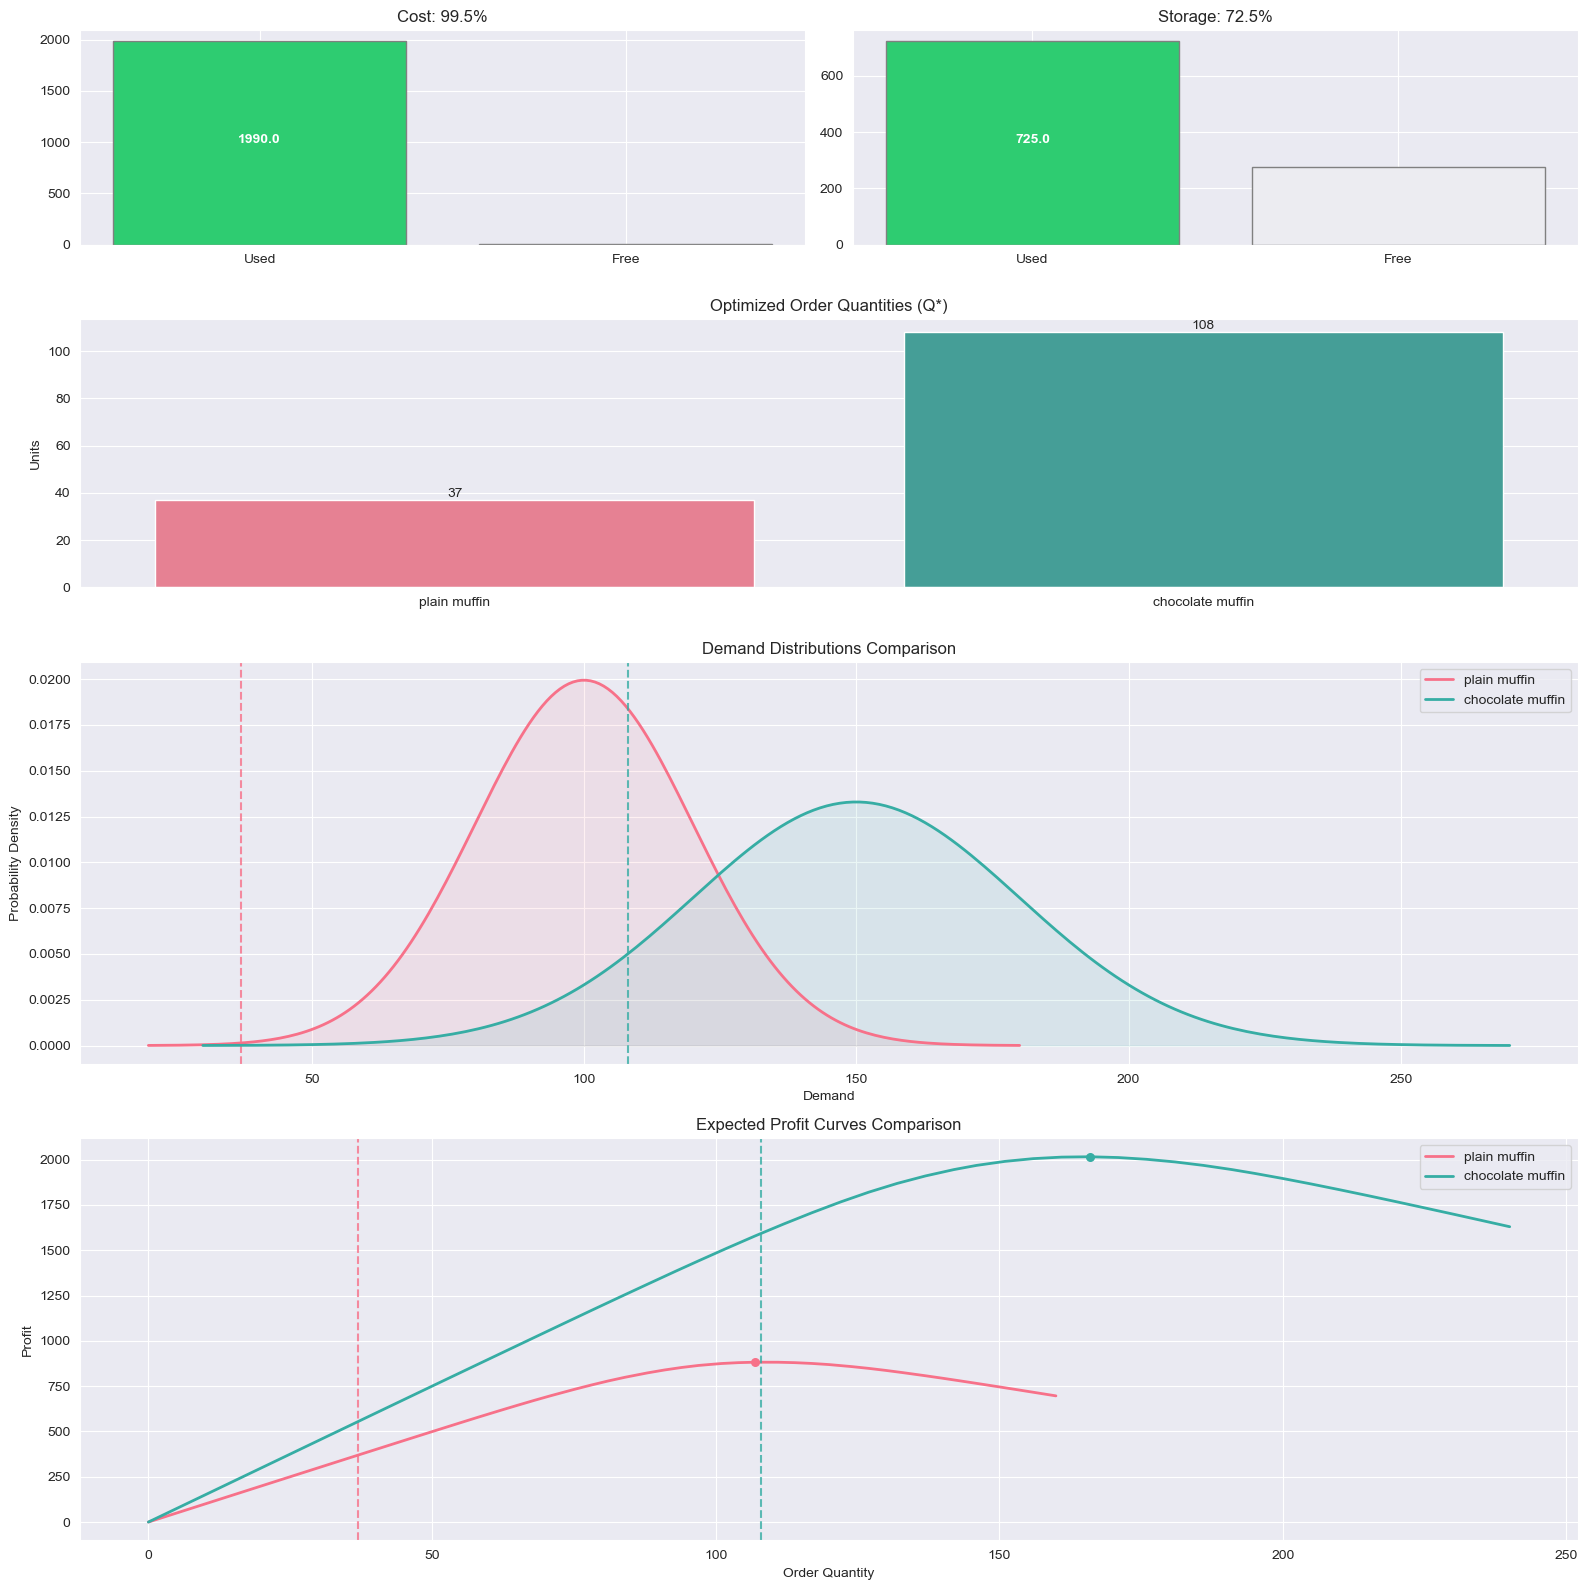

In [2]:
from optistock.plot_suite.portfolio import plot_constrained_allocation
results = plot_constrained_allocation(
    res_averse, problems, solver.limits
)

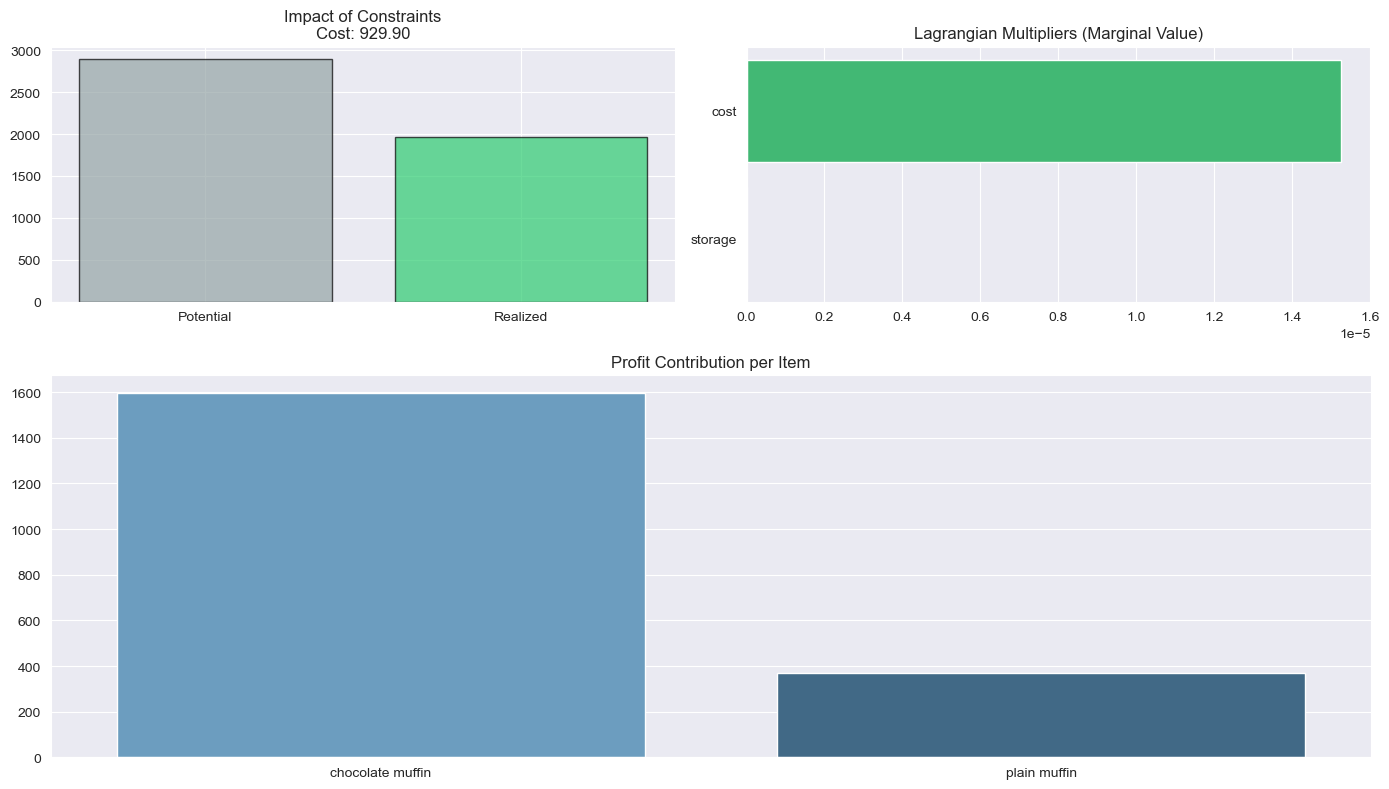

In [3]:
from optistock.plot_suite.portfolio import plot_optimization_summary
fig = plot_optimization_summary(res_averse, problems, solver.lambdas)

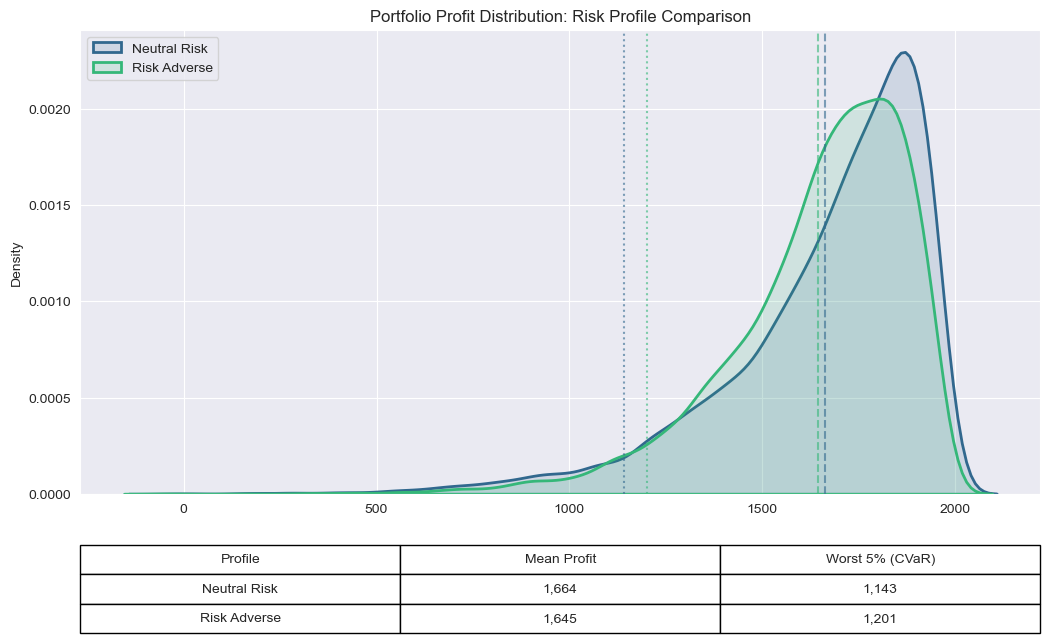

In [4]:
from optistock.plot_suite.risk import plot_risk_comparison
fig = plot_risk_comparison(
    {"Neutral Risk": res_neutral, "Risk Adverse": res_averse}, problems=problems
)